In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from functools import partial
from einops import rearrange
from scipy.interpolate import RectBivariateSpline
from scipy.ndimage import gaussian_filter
from tqdm import tqdm

import sys
sys.path.append("../")

from utils import create_mask as cm
from utils.pdf_sampler import PDFSampler
from models.psf import KingPSF

%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pylab as pylab
import warnings
import matplotlib.cbook

from plot_params import params

warnings.filterwarnings("ignore",category=matplotlib.cbook.mplDeprecation)

pylab.rcParams.update(params)
cols_default = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [3]:
from reproject import reproject_from_healpix, reproject_to_healpix
from astropy.wcs import WCS
from astropy.coordinates import ICRS, Galactic

In [4]:
from utils.cart import make_wcs, to_cart

In [5]:
cmap = 'RdBu_r'

## Templates

In [6]:
extent = 25
n_pixels = 100
pixelsize = 2 * extent / n_pixels
upsample_factor = 8
nside = 128
sigma_psf = 0.1812

In [7]:
fermi_data_cart = to_cart(np.load("../data/fermi_data/fermidata_counts.npy"), n_pixels=n_pixels, pixelsize=pixelsize)

# Load standard templates
temp_gce_cart = to_cart(np.load("../data/fermi_data/template_gce.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_dif_cart = to_cart(np.load("../data/fermi_data/template_dif.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_psc_cart = to_cart(np.load("../data/fermi_data/template_psc.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_iso_cart = to_cart(np.load("../data/fermi_data/template_iso.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_dsk_cart = to_cart(np.load("../data/fermi_data/template_dsk.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_bub_cart = to_cart(np.load("../data/fermi_data/template_bub.npy"), n_pixels=n_pixels, pixelsize=pixelsize)

mask_ps = np.load("../data/fermi_data/fermidata_pscmask.npy") == 1

# Load original exposure
exp_original = to_cart(np.load("../data/fermi_data/fermidata_exposure.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
exp_original_norm = exp_original / np.mean(exp_original)

# Load Model O templates
temp_mO_pibrem_cart = to_cart(np.load("../data/fermi_data/ModelO_r25_q1_pibrem.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_mO_ics_cart = to_cart(np.load("../data/fermi_data/ModelO_r25_q1_ics.npy"), n_pixels=n_pixels, pixelsize=pixelsize)

# ROI mask
mask_roi = to_cart(cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=2., mask_ring=True, inner=0, outer=60., custom_mask=mask_ps), n_pixels=n_pixels, pixelsize=pixelsize) > 0


## Exposure of real data

In [8]:
from astropy.io import fits

In [9]:
exp_fits = fits.open("/n/holyscratch01/iaifi_lab/yitians/exposure_ultracleanveto_bestpsf_joined.fits")

pixel_size_data = 0.1
pixel_size_target = 0.5
upsample_factor_data = int(pixel_size_target / pixel_size_data)
extent = 25
i_e = 40

In [10]:
exp = exp_fits[0].data[i_e:i_e + 11].sum(0)[int((90 - extent) / pixel_size_data):int((90 + extent) / 0.1),int((90 - extent) / 0.1):int((90 + extent) / pixel_size_data)]
b = exp.shape[0] // upsample_factor_data
exp_downsampled = exp.reshape(-1, upsample_factor_data, b, upsample_factor_data).sum((-1, -3))
exp_downsampled_norm = exp_downsampled / np.mean(exp_downsampled)

exp_ratio = exp_original_norm / exp_downsampled_norm

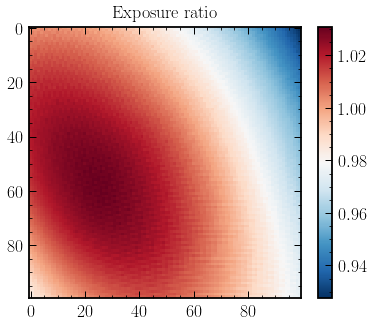

In [11]:
fig, ax = plt.subplots()
im = ax.imshow(exp_ratio, cmap=cmap)
ax.set_title("Exposure ratio")
fig.colorbar(im, ax=ax)

## Sims

In [12]:
from models.scd import dnds

In [13]:
# Templates
temps_ps = np.array([temp_gce_cart / exp_original_norm, temp_dsk_cart / exp_original_norm])
temps_poiss = np.array([temp_gce_cart * exp_ratio, temp_iso_cart * exp_ratio, temp_bub_cart * exp_ratio, temp_psc_cart * exp_ratio, temp_mO_pibrem_cart * exp_ratio, temp_mO_ics_cart * exp_ratio])

# Make upsampled versions of PS templates

temps_ps_upsampled = []

mesh_dim = np.linspace(0, n_pixels, n_pixels * upsample_factor)

for temp_ps in temps_ps:
    interp = RectBivariateSpline(np.arange(n_pixels), np.arange(n_pixels), temp_ps)
    temp_ps_upsampled = interp(mesh_dim, mesh_dim)
    temps_ps_upsampled.append(temp_ps_upsampled)
    
interp = RectBivariateSpline(np.arange(n_pixels), np.arange(n_pixels), exp_downsampled_norm)
exp_upsampled_norm = interp(mesh_dim, mesh_dim)

In [14]:
def simulate(n_sim=300000):
    
    # Priors

    prior_ps = [[0.001, 10.0, 1.1, -10.0, 5.0, 1., 0.001, 10.0, 1.1, -10.0, 5.0, 1.], 
                [3., 20.0, 1.99, 1.99, 40.0, 4.99, 3., 20.0, 1.99, 1.99, 40.0, 4.99]]

    prior_poiss = [[0.001, 0.001, 0.001, 0.001, 10.0, 4.0], 
                   [3., 1.5, 1.5, 4., 20.0, 8.0]]
    
    # Generate parameters from prior
    thetas = np.random.uniform(low=prior_poiss[0] + prior_ps[0], high=prior_poiss[1] + prior_ps[1], size=(n_sim, len(prior_ps[0]) + len(prior_poiss[0])))

    s_ary = np.logspace(-1, 2, 1000)
    logs_ary = np.log10(s_ary)
    dlogs_ary = np.diff(logs_ary)[0] # Spacing in log-space

    s_for_ds_ary = np.logspace(logs_ary[0] - dlogs_ary / 2.0, logs_ary[-1] + dlogs_ary / 2.0, len(s_ary) + 1)
    ds_ary = np.diff(s_for_ds_ary)

    signal_ensemble = np.zeros((n_sim, n_pixels, n_pixels))
    flux_fraction = np.zeros((n_sim, len(temps_ps) + len(temps_poiss)))
    dnds_ary = []

    for idx_theta, theta in enumerate(tqdm(thetas)):

        idx_theta_ps = len(temps_poiss)

        for idx, temp_ps in enumerate(temps_ps):

            dnds_ary_temp = dnds(s_ary, theta[idx_theta_ps:idx_theta_ps + 6])
            s_exp = np.trapz(s_ary * dnds_ary_temp, s_ary)
            dnds_ary_temp *= theta[idx_theta_ps] * np.prod(temp_ps.shape) / s_exp
            dnds_ary.append(dnds_ary_temp)
            idx_theta_ps += 6

            n_ps = np.random.poisson(np.trapz(dnds_ary_temp, s_ary))

            # Sample, accounting for dS factor for log-space sampling
            sample = PDFSampler(s_ary, ds_ary * dnds_ary_temp)(n_ps)

            dist = temps_ps_upsampled[idx]
            dist /= dist.sum() 
            pairs = np.indices(dimensions=temps_ps_upsampled[idx].shape).T # here are all of the x,y pairs 
            inds = np.random.choice(np.arange(np.prod(temps_ps_upsampled[idx].shape)), p=dist.reshape(-1),size=n_ps,replace=True)
            selections = pairs.reshape(-1, 2)[inds]
            hist = np.histogram2d(x=selections[:, 1], y=selections[:, 0], bins=n_pixels * upsample_factor, weights=sample)[0]

            sigma_mu = gaussian_filter(hist, sigma=sigma_psf / (pixelsize / upsample_factor), truncate=8.)
            sigma_mu *= exp_upsampled_norm
            signal = np.random.poisson(sigma_mu)

            b = signal.shape[0] // upsample_factor
            signal_reshaped = signal.reshape(-1, upsample_factor, b, upsample_factor).sum((-1, -3))

            signal_ensemble[idx_theta, :, :] += signal_reshaped

            flux_fraction[idx_theta, idx] = signal_reshaped.mean()
        
        theta[0] /= temps_poiss[0].mean()
        
        flux_fraction[idx_theta, 2:] = (temps_poiss.T * theta[:len(temps_poiss)]).mean((0,1))
        signal_ensemble[idx_theta, :, :] += np.random.poisson(np.einsum('i,ijk->jk', theta[:len(temps_poiss)], temps_poiss))

    flux_fraction = (flux_fraction.T / flux_fraction.sum(1)).T
    
    return signal_ensemble, flux_fraction

In [249]:
signal_ensemble, flux_fraction = simulate(10)

100%|██████████| 10/10 [00:01<00:00,  7.61it/s]


In [250]:
signal_ensemble.mean(axis=(1,2))

array([43.48  , 46.8765, 52.2592, 38.0377, 40.0839, 35.2658, 40.2618,
       51.3094, 46.3736, 45.4542])

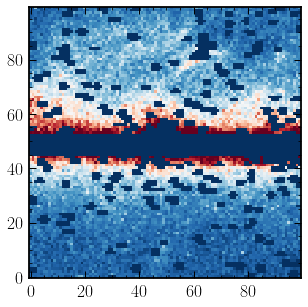

In [251]:
plt.imshow(signal_ensemble[2] * ~mask_roi, vmin=0, vmax=100, origin='lower', cmap=cmap)

In [47]:
np.savez("../data/samples/data_uniform.npz", signal_ensemble=signal_ensemble, flux_fraction=flux_fraction)

In [15]:
x_test, theta_test = simulate(500)

100%|██████████| 500/500 [01:08<00:00,  7.30it/s]


In [16]:
np.save("../data/samples/x_test.npy", x_test)
np.save("../data/samples/theta_test.npy", theta_test)

In [ ]:
np.savez("../data/samples/data_uniform_test.npz", signal_ensemble=signal_ensemble, flux_fraction=flux_fraction)

In [50]:
np.savez("../data/samples/data_uniform_test.npz", signal_ensemble=signal_ensemble, flux_fraction=flux_fraction)

In [176]:
counts_fits = fits.open("/n/holyscratch01/iaifi_lab/yitians/ccube_ultracleanveto_bestpsf_joined.fits")

pixel_size_data = 0.1
pixel_size_target = 0.5
extent = 25
i_e = 40

upsample_factor = int(pixel_size_target / pixel_size_data)

counts = counts_fits[0].data[i_e:i_e + 11].sum(0)[int((90 - extent) / 0.1):int((90 + extent) / 0.1),int((90 - extent) / 0.1):int((90 + extent) / 0.1)]
b = counts.shape[0] // upsample_factor
counts_downsampled = counts.reshape(-1, upsample_factor, b, upsample_factor).sum((-1, -3))

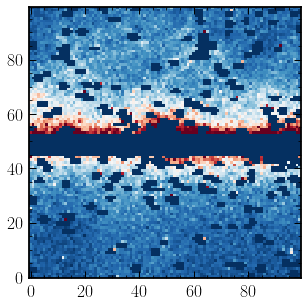

In [252]:
plt.imshow(counts_downsampled * ~mask_roi, vmin=0, vmax=100, origin='lower', cmap=cmap)

In [253]:
(signal_ensemble).max()

9351.0

In [254]:
(counts_downsampled).max()

6330

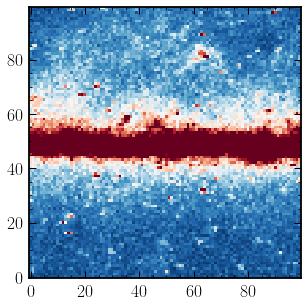

In [255]:
plt.imshow(signal_ensemble[1], vmin=0, vmax=100, origin='lower', cmap=cmap)

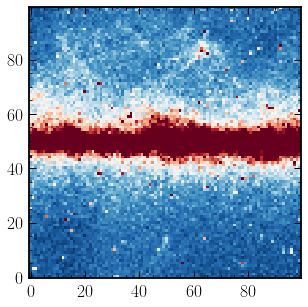

In [256]:
plt.imshow(counts_downsampled, vmin=0, vmax=100, origin='lower', cmap=cmap)